## Overview
This notebook implements an automated pipeline to solve the **ML-CUP25 Regression Task** using an **Ensemble of Small Models**.

## Workflow
1.  **Data Loading**: 
    - Loads `ML-CUP25-TR.csv` and splits it into **Train**, **Validation** (20%), and **Blind Test**.

2.  **Architecture Search (Optuna)**: 
    - We use **Optuna** to find the best hyperparameters for a *single* small model.
    - **Constraints**: 
        - Depth: 1 to 2 hidden layers.
        - Width: 8 to 64 neurons per layer.
    - **Goal**: Minimize MSE on the Validation Set.

3.  **Ensemble Training**: 
    - We take the *best* architecture found by Optuna.
    - We instantiate **5 independent copies** of this model (the "Ensemble").
    - Each copy is trained from scratch with different random initializations.

4.  **Final Evaluation**:
    - The ensemble's prediction is the **average** of all 5 members.
    - We report the final MSE on the Validation and Test sets.

## How to Use
1.  **Prerequisites**: Ensure `data_loader.py` and the `models/` folder are in the same directory.
2.  **Configuration**: Adjust the constants in the first code cell (e.g., `N_TRIALS`, `ENSEMBLE_SIZE`) to control runtime.
3.  **Run All**: Execute all cells in order. The Optuna search will run first, followed automatically by the ensemble training.

In [ ]:
#--- 1. IMPORTS ---
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import optuna
import matplotlib.pyplot as plt
import sys
from sklearn.decomposition import PCA

# Ensure we can import from local modules
sys.path.append(os.getcwd())

# Import your custom modules
from utils.data_loader import get_ml_cup_data
from models import StandardFeedForwardNet, EnsembleModel
from models.ensemble import ModelWithHead, ReadoutAdapter
import training_utils

# --- CONFIGURATION ---
N_TRIALS = 1000
N_EPOCHS_SEARCH = 150
BATCH_SIZE = 64
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")

print(f"Using device: {DEVICE}")

c:\Users\Michael\Desktop\Rage-Against-ML\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


⚠️  Warning: Keras/TensorFlow utils not loaded. Reason: No module named 'keras'
Using device: cpu


In [2]:
# --- 2. RUN OPTUNA SEARCH & ANALYZE TOP 5 (WITH PROGRESS BAR) ---
import sys
import optuna
import subprocess
import time
import pandas as pd
from IPython.display import display
from tqdm import tqdm  # <--- CHANGED: Standard text-based tqdm, not .notebook

# 1. Run the external script in a background process
print(f"Starting Optuna Search (External Script)...")
cmd = [sys.executable, "optuna_search_mlcup_nn.py", "--n_trials", str(N_TRIALS), "--epochs", str(N_EPOCHS_SEARCH)]
process = subprocess.Popen(cmd)

# 2. Monitor Progress Bar
db_url = "sqlite:///optuna_mlcup_nn.db"
pbar = tqdm(total=N_TRIALS, desc="Optuna Trials", unit="trial")

try:
    while process.poll() is None:  # Keep running while the subprocess is alive
        try:
            # Connect to DB securely
            temp_storage = optuna.storages.RDBStorage(url=db_url)
            
            try:
                study_temp = optuna.load_study(study_name="mlcup_search", storage=temp_storage)
                current_trials = len(study_temp.trials)
                pbar.n = current_trials
                pbar.refresh()
            except (KeyError, ValueError):
                pass
            
            # Dispose to release lock
            temp_storage.engine.dispose()
            del temp_storage
            
        except Exception:
            pass # Ignore transient errors
            
        time.sleep(2)  # Check every 2 seconds

except KeyboardInterrupt:
    print("Stopping external script...")

# Ensure bar is full and closed
pbar.n = N_TRIALS 
pbar.refresh()
pbar.close()
print("External script finished.")

# 3. Access Results Safely
storage = optuna.storages.RDBStorage(url=db_url)

try:
    study = optuna.load_study(study_name="mlcup_search", storage=storage)
    df = study.trials_dataframe()
    df = df[df.state == "COMPLETE"]
    
    if not df.empty:
        top_5 = df.sort_values('value', ascending=True).head(5)
        cols_to_show = ['number', 'value'] + [c for c in df.columns if c.startswith('params_')]

        print(f"\nSearch Complete. Best Params: {study.best_params}")
        display(top_5[cols_to_show])
        best_params = study.best_params
    else:
        print("No complete trials found.")

finally:
    storage.engine.dispose()
    del storage

Starting Optuna Search (External Script)...


Optuna Trials: 100%|██████████| 100/100 [11:29<00:00,  6.90s/trial]

External script finished.

Search Complete. Best Params: {'scaler': 'standard', 'scale_target': True, 'n_layers': 2, 'hidden_size': 21, 'dropout': 0.12593637681071962, 'weight_decay': 6.924280781563029e-05, 'activation': 'relu', 'lr': 0.03847212024933485}


,number,value,params_activation,params_dropout,params_hidden_size,params_lr,params_n_layers,params_scale_target,params_scaler,params_weight_decay
98,98,161.260345,relu,0.125936,21,0.038472,2,True,standard,0.000069
73,73,162.102448,relu,0.292563,22,0.076567,1,True,standard,0.000020
76,76,164.078476,relu,0.242643,19,0.044660,1,True,standard,0.000030
91,91,164.949432,relu,0.195398,19,0.038092,1,True,standard,0.000045
71,71,165.079483,relu,0.284644,21,0.045963,1,True,standard,0.000013


In [6]:
# --- 3. TRAINING ENSEMBLE (WITH K-FOLD & NOISE) ---
import copy
import math
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
from sklearn.model_selection import KFold
from sklearn.decomposition import PCA
from torch.utils.data import DataLoader

# Import your custom modules
from models.standard import StandardFeedForwardNet
from models.ensemble import ModelWithHead, ReadoutAdapter, EnsembleModel
from utils.data_loader import MLCupDataset, GaussianNoise, get_ml_cup_data
import training_utils

# --- SETTINGS FOR ENSEMBLE, CV & NOISE ---
N_EPOCHS_FINAL = 2000    # Train the final ensemble longer
ENSEMBLE_SIZE = 10         # How many models to stack together
K_FOLDS = 5               # Number of Folds
NOISE_STD = 0.15          # Strength of Gaussian Noise
USE_NOISE = False          # Enable/Disable Noise
N_COMPONENTS = 0

# 1. Retrieve Best Hyperparameters
params = study.best_params
lr = params['lr']
weight_decay = params.get('weight_decay', 0.0)
use_target_scaling = params.get('scale_target', False) # Get scaling preference from Optuna

print(f"\nTraining Ensemble via {K_FOLDS}-fold Cross-Validation...")
print(f"Best Params: {params}")
print(f"Gaussian Noise Injection: {'ENABLED (std=' + str(NOISE_STD) + ')' if USE_NOISE else 'DISABLED'}")
print(f"Target Scaling: {use_target_scaling}")

# ==============================================================================
# 2. RELOAD DATA TO MATCH OPTUNA SETTINGS
# We must reload data because Optuna might have chosen scale_target=True, 
# but the previous cells might have had scale_target=False.
# ==============================================================================
train_loader, val_loader, test_loader, INPUT_SIZE, OUTPUT_SIZE, target_scaler = get_ml_cup_data(
    BATCH_SIZE, 
    validation_ratio=0.15,
    test_ratio=0.10,
    scale_target=use_target_scaling, # Use the optimized flag
    num_workers=0
)

# Re-apply PCA if it was active (assuming N_COMPONENTS is defined in previous cell)
if 'N_COMPONENTS' in globals() and N_COMPONENTS > 0:
    print(f"Re-applying PCA with {N_COMPONENTS} components on new data...")
    pca = PCA(n_components=N_COMPONENTS)
    
    # Fit on Train, Transform All
    X_train_pca = pca.fit_transform(train_loader.dataset.X.numpy())
    X_val_pca   = pca.transform(val_loader.dataset.X.numpy())
    X_test_pca  = pca.transform(test_loader.dataset.X.numpy())
    
    # Update Datasets
    train_loader.dataset.X = torch.tensor(X_train_pca, dtype=torch.float32)
    val_loader.dataset.X   = torch.tensor(X_val_pca, dtype=torch.float32)
    test_loader.dataset.X  = torch.tensor(X_test_pca, dtype=torch.float32)
    
    INPUT_SIZE = N_COMPONENTS # Update input dimension

# Merge Train+Val for K-Fold
X_dev = torch.cat([train_loader.dataset.X, val_loader.dataset.X], dim=0)
y_dev = torch.cat([train_loader.dataset.y, val_loader.dataset.y], dim=0)

# ==============================================================================
# 3. START ENSEMBLE TRAINING
# ==============================================================================

models_per_fold = math.ceil(ENSEMBLE_SIZE / K_FOLDS) 
print(f"Total Ensemble Size: {ENSEMBLE_SIZE} | Models per Fold: {models_per_fold}")

# Containers
members = []
cv_val_scores = [] 
train_losses = [] # For plotting later
val_mses = []     # For plotting later

kf = KFold(n_splits=K_FOLDS, shuffle=True, random_state=42)

# Global Progress Bar
total_epochs = K_FOLDS * N_EPOCHS_FINAL
pbar = tqdm(total=total_epochs, desc="CV Training", unit="epoch")

for fold_idx, (train_idx, val_idx) in enumerate(kf.split(X_dev)):
    # --- A. Prepare Data for this Fold ---
    X_train_fold = X_dev[train_idx]
    y_train_fold = y_dev[train_idx]
    X_val_fold   = X_dev[val_idx]
    y_val_fold   = y_dev[val_idx]
    
    # Define Noise Transform (Applied ONLY to Training Data)
    train_noise = GaussianNoise(std=NOISE_STD, active=USE_NOISE)
    
    # Create Datasets & Loaders
    train_ds = MLCupDataset(X_train_fold, y_train_fold, transform=train_noise)
    val_ds   = MLCupDataset(X_val_fold, y_val_fold, transform=None) 
    
    loader_t = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    loader_v = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
    
    # --- B. Train Models for this Fold ---
    for m_idx in range(models_per_fold):
        if len(members) >= ENSEMBLE_SIZE: break
            
        # 1. Instantiate Model (Params from Optuna)
        hidden_sizes = [params['hidden_size']] * 2 # Assuming 2 layers, or adjust based on study
        
        base = StandardFeedForwardNet(
            input_size=INPUT_SIZE,
            hidden_sizes=hidden_sizes,
            output_size=OUTPUT_SIZE,
            activation=params['activation'],
            dropout=params.get('dropout', 0.0)
        )
        model = ModelWithHead(base, ReadoutAdapter(OUTPUT_SIZE, OUTPUT_SIZE, 'regression')).to(DEVICE)
        
        # 2. Optimizer
        opt = optim.SGD(
            model.parameters(), 
            lr=lr, 
            weight_decay=weight_decay,
            momentum=0.9,
            nesterov=True
        )
        
        criterion = nn.MSELoss()
        
        # 3. Training Loop
        best_mse = float('inf')
        best_weights = None
        
        for epoch in range(N_EPOCHS_FINAL):
            model.train()
            train_loss_accum = 0
            samples = 0
            
            for data, target in loader_t:
                data, target = data.to(DEVICE), target.to(DEVICE)
                opt.zero_grad()
                out = model(data)
                loss = criterion(out, target)
                
                # --- SAFETY: Check for NaN ---
                if torch.isnan(loss):
                    continue # Skip bad batch to avoid weight corruption
                
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                opt.step()
                
                train_loss_accum += loss.item() * data.size(0)
                samples += data.size(0)
            
            avg_train_loss = train_loss_accum / samples if samples > 0 else 0
            
            # Validation
            val_mse = training_utils.evaluate(model, loader_v, criterion, DEVICE, target_scaler=target_scaler)
            
            # Save stats for plotting (just append to global list for simple visualization)
            if m_idx == 0 and fold_idx == 0: # Only track first model to keep plot clean
                train_losses.append(avg_train_loss)
                val_mses.append(val_mse)

            # Save Best Weights
            if val_mse < best_mse:
                best_mse = val_mse
                best_weights = copy.deepcopy(model.state_dict())
            
            pbar.update(1)
            pbar.set_postfix({
                'Fold': f"{fold_idx+1}/{K_FOLDS}",
                'M': f"{len(members)+1}",
                'MSE': f"{val_mse:.4f}",
                'Best': f"{best_mse:.4f}"
            })

        # Restore best weights and save model
        if best_weights is not None:
            model.load_state_dict(best_weights)
        members.append(model)
        cv_val_scores.append(best_mse)

pbar.close()

# --- C. Finalize Ensemble ---
ensemble = EnsembleModel(members, weights=[1.0]*len(members)).to(DEVICE)

print("\n" + "="*40)
print(f"Ensemble Training Complete.")
print(f"Total Models: {len(members)}")
print(f"Average CV Score (MSE): {np.mean(cv_val_scores):.4f} (+/- {np.std(cv_val_scores):.4f})")
print("="*40)


Training Ensemble via 5-fold Cross-Validation...
Best Params: {'scaler': 'standard', 'scale_target': True, 'n_layers': 2, 'hidden_size': 21, 'dropout': 0.12593637681071962, 'weight_decay': 6.924280781563029e-05, 'activation': 'relu', 'lr': 0.03847212024933485}
Gaussian Noise Injection: DISABLED
Target Scaling: True
Parsing ML-CUP data (TR only)...
Data Split: Train=375, Val=75, Internal Test=50
Applying scaling StandardScaler to Inputs...
Applying StandardScaler to Targets...
Total Ensemble Size: 10 | Models per Fold: 2


CV Training: 20000epoch [03:33, 93.76epoch/s, Fold=5/5, M=10, MSE=167.8729, Best=148.2952]                       


Ensemble Training Complete.
Total Models: 10
Average CV Score (MSE): 130.5022 (+/- 14.6704)



Plotting convergence graph...


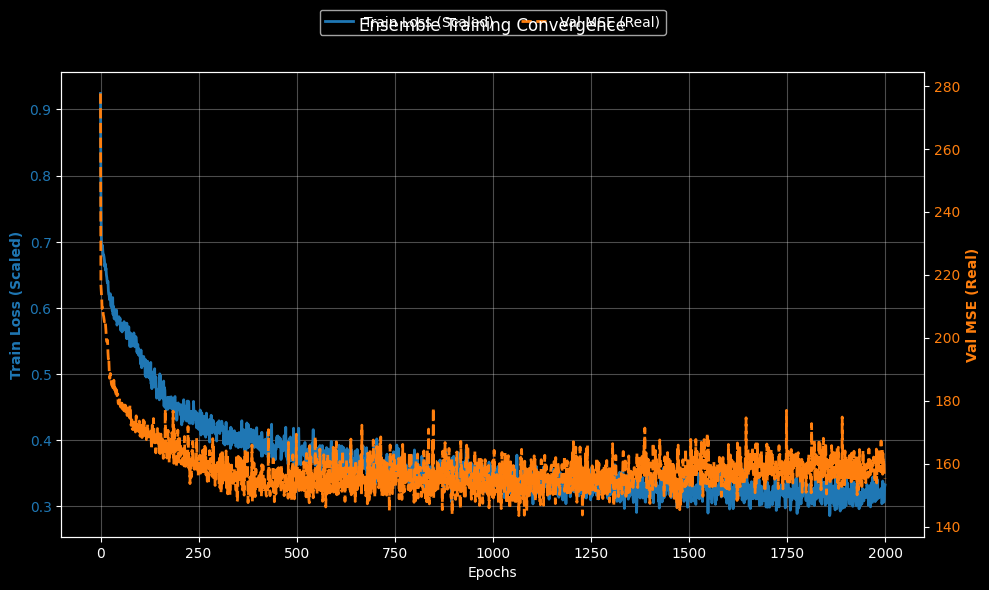

In [7]:
import matplotlib.pyplot as plt

# --- 4. PLOT CONVERGENCE ---
print("\nPlotting convergence graph...")

plt.figure(figsize=(10, 6))
ax1 = plt.gca()

# Plot Training Loss (Scaled) on Left Y-Axis
color = 'tab:blue'
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Train Loss (Scaled)', color=color, fontweight='bold')
line1 = ax1.plot(train_losses, color=color, label='Train Loss (Scaled)', linewidth=2)
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, alpha=0.3)

# Create Second Y-Axis for Validation MSE (Real)
ax2 = ax1.twinx()  
color = 'tab:orange'
ax2.set_ylabel('Val MSE (Real)', color=color, fontweight='bold')
line2 = ax2.plot(val_mses, color=color, label='Val MSE (Real)', linewidth=2, linestyle='--')
ax2.tick_params(axis='y', labelcolor=color)

# Combine legends
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=2)

plt.title('Ensemble Training Convergence', pad=30)
plt.tight_layout()

plt.show()

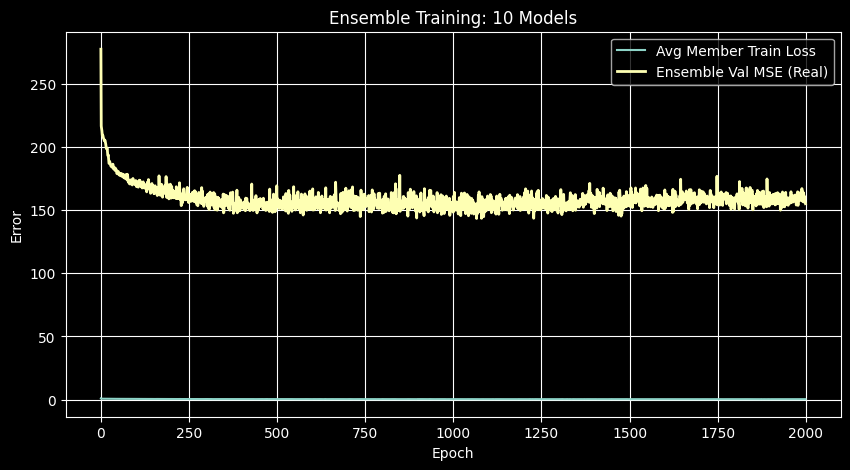

Evaluating Ensemble on Internal Test Set...

FINAL TEST RESULT
Mean Euclidean Error (MEE): 18.5133
Target Range (Y1): -32.54 to 25.74
Target Range (Y2): -31.71 to 27.65
Target Range (Y3): -61.22 to 41.89
Target Range (Y4): -39.70 to 43.89


In [8]:
# --- 5. RESULTS, PLOT & MEE CALCULATION ---
import numpy as np
import matplotlib.pyplot as plt
import torch

# 1. Plot Training History
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Avg Member Train Loss')
plt.plot(val_mses, label='Ensemble Val MSE (Real)', linewidth=2)
plt.title(f"Ensemble Training: {ENSEMBLE_SIZE} Models")
plt.xlabel("Epoch")
plt.ylabel("Error")
plt.legend()
plt.grid(True)
plt.show()

# 2. Final Evaluation on INTERNAL TEST SET (MEE Calculation)
print("Evaluating Ensemble on Internal Test Set...")

ensemble.eval()
total_mee = 0.0
total_samples = 0

# We'll keep track of the last batch to print ranges at the end
last_target_real = None 

with torch.no_grad():
    for data, target in test_loader:
        data, target = data.to(DEVICE), target.to(DEVICE)
        
        # Get ensemble predictions (already averaged inside the model)
        out = ensemble(data)
        
        # --- INVERSE TRANSFORM TO REAL UNITS ---
        # Move to CPU and numpy
        out_np = out.cpu().numpy()
        target_np = target.cpu().numpy()
        
        if target_scaler is not None:
            # If scaler exists, reverse the scaling
            out_real = target_scaler.inverse_transform(out_np)
            target_real = target_scaler.inverse_transform(target_np)
        else:
            # If no scaler (None), data is already real
            out_real = out_np
            target_real = target_np
            
        last_target_real = target_real # Save for printing later
        
        # --- CALCULATE MEE (Mean Euclidean Error) ---
        # 1. Difference vector
        diff = out_real - target_real
        
        # 2. Euclidean distance for each sample: sqrt(sum(diff^2))
        # axis=1 sums across the output dimensions (e.g., x and y coordinates)
        euclidean_dists = np.sqrt(np.sum(diff**2, axis=1))
        
        # 3. Accumulate sum of distances
        total_mee += np.sum(euclidean_dists)
        total_samples += data.size(0)

# Final Average
final_mee = total_mee / total_samples

print("\n" + "="*40)
print(f"FINAL TEST RESULT")
print(f"Mean Euclidean Error (MEE): {final_mee:.4f}")
print("="*40)

# Check the range of the REAL targets (using the last batch processed)
if last_target_real is not None:
    print("Target Range (Y1):", f"{last_target_real[:, 0].min():.2f}", "to", f"{last_target_real[:, 0].max():.2f}")
    print("Target Range (Y2):", f"{last_target_real[:, 1].min():.2f}", "to", f"{last_target_real[:, 1].max():.2f}")
    print("Target Range (Y3):", f"{last_target_real[:, 2].min():.2f}", "to", f"{last_target_real[:, 2].max():.2f}")
    print("Target Range (Y4):", f"{last_target_real[:, 3].min():.2f}", "to", f"{last_target_real[:, 3].max():.2f}")
print("="*40)

In [ ]:
# --- EXTRA. TARGET DISTRIBUTION ANALYSIS (Scaled vs Unscaled) ---
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler

# 1. Recover Raw Targets from Train Loader
# We extract the Y tensor and move to numpy
y_train_scaled = train_loader.dataset.y.numpy()

# If targets were scaled in loader, we inverse transform them to get raw
if target_scaler:
    y_train_raw = target_scaler.inverse_transform(y_train_scaled)
else:
    y_train_raw = y_train_scaled

# 2. Define Scalers to Compare
scalers = {
    "Unscaled (Raw)": None,
    "StandardScaler (Z-score)": StandardScaler(),
    "MinMaxScaler (0-1)": MinMaxScaler(),
    "RobustScaler (Quantile)": RobustScaler()
}

# 3. Plot Distributions for each Target Dimension (Y1 to Y4)
num_targets = y_train_raw.shape[1]
fig, axes = plt.subplots(num_targets, len(scalers), figsize=(20, 4 * num_targets))

print("Generating Target Distribution Plots and Statistics...")

# Set pandas display options for better readability of the describe() output
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', '{:.3f}'.format)

for dim_i in range(num_targets):
    target_name = f"Target_Y{dim_i+1}"
    
    # Dictionary to collect data for this target across all scalers for describe()
    comparison_data = {}

    for idx, (scaler_name, scaler_obj) in enumerate(scalers.items()):
        ax = axes[dim_i, idx]
        
        # Transform data
        if scaler_obj is None:
            data_to_plot = y_train_raw[:, dim_i]
        else:
            # Fit on full raw y and transform (we fit on all targets, then extract the specific dim)
            transformed_y = scaler_obj.fit_transform(y_train_raw)
            data_to_plot = transformed_y[:, dim_i]
            
        # Add to comparison dictionary
        comparison_data[scaler_name] = data_to_plot
        
        # Plot Histogram & KDE
        sns.histplot(data_to_plot, kde=True, ax=ax, color='skyblue', edgecolor='black')
        
        # Formatting
        ax.set_title(f"{target_name} | {scaler_name}")
        ax.set_xlabel("Value")
        ax.set_ylabel("Frequency")
        
        # Add stats annotation (Mean/Std) to the plot
        mu = np.mean(data_to_plot)
        std = np.std(data_to_plot)
        ax.annotate(f"Mean: {mu:.2f}\nStd: {std:.2f}", 
                    xy=(0.05, 0.95), xycoords='axes fraction', 
                    bbox=dict(boxstyle="round", fc="white", alpha=0.8),
                    verticalalignment='top')
    
    # --- PRINT DESCRIBE() TABLE FOR CURRENT TARGET ---
    print(f"\n{'='*20} STATISTICS FOR {target_name} {'='*20}")
    df_compare = pd.DataFrame(comparison_data)
    print(df_compare.describe())
    print("-" * 80)

plt.tight_layout()
plt.show()

In [ ]:
# --- EXTRA. OPTUNA RESULTS ANALYSIS & VISUALIZATION ---
import optuna
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from optuna.visualization.matplotlib import plot_optimization_history, plot_param_importances, plot_slice

# 1. Load the Study
db_url = "sqlite:///optuna_mlcup_nn.db"
study_name = "mlcup_search"

try:
    storage = optuna.storages.RDBStorage(url=db_url)
    study = optuna.load_study(study_name=study_name, storage=storage)
    
    print(f"Study '{study_name}' loaded successfully.")
    print(f"Total Trials: {len(study.trials)}")
    
    # 2. Display Best Trial Details
    best_trial = study.best_trial
    print("\n" + "="*40)
    print("BEST TRIAL RESULTS")
    print("="*40)
    print(f"  Value (Validation MSE): {best_trial.value:.6f}")
    print(f"  Trial Number: {best_trial.number}")
    print("  Params:")
    for key, value in best_trial.params.items():
        print(f"    {key}: {value}")
    print("="*40 + "\n")

    # 3. Convert to DataFrame for Custom Analysis
    df = study.trials_dataframe()
    # Filter only complete trials
    df_success = df[df.state == "COMPLETE"].copy()
    
    # Rename columns for readability (remove 'params_' prefix)
    df_success.columns = [col.replace('params_', '') for col in df_success.columns]
    
    # Sort by value (MSE)
    top_10 = df_success.sort_values('value').head(10)
    print("Top 10 Trials:")
    display(top_10[['number', 'value'] + list(best_trial.params.keys())])

    # --- PLOTS ---
    # Set general style
    plt.style.use('seaborn-v0_8-whitegrid')
    
    # A. Optimization History (Did we converge?)
    plt.figure(figsize=(10, 6))
    plot_optimization_history(study)
    plt.title("Optimization History (Validation MSE)", fontsize=14)
    plt.xlabel("Trial")
    plt.ylabel("MSE")
    plt.tight_layout()
    plt.show()

    # B. Hyperparameter Importance (What matters most?)
    try:
        plt.figure(figsize=(10, 6))
        plot_param_importances(study)
        plt.title("Hyperparameter Importance", fontsize=14)
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"Could not plot importance: {e}")

    # C. Slice Plots (Individual Parameter Trends)
    # We create a custom slice plot using Seaborn for better control than Optuna's default
    params_to_plot = list(best_trial.params.keys())
    n_params = len(params_to_plot)
    n_cols = 3
    n_rows = (n_params + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
    axes = axes.flatten()

    for i, param in enumerate(params_to_plot):
        sns.scatterplot(data=df_success, x=param, y='value', ax=axes[i], alpha=0.7, color='teal')
        
        # Highlight best value
        best_val_param = best_trial.params[param]
        axes[i].axvline(best_val_param, color='red', linestyle='--', label='Best')
        
        axes[i].set_title(f"{param} vs MSE")
        axes[i].set_ylabel("Validation MSE")
        axes[i].legend()
        
        # Log scale for learning rate and weight decay usually looks better
        if param in ['lr', 'weight_decay']:
            axes[i].set_xscale('log')

    # Hide empty subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.suptitle("Parameter Slices (Lower MSE is better)", y=1.02, fontsize=16)
    plt.show()

except Exception as e:
    print(f"Error loading study or plotting: {e}")
    print("Make sure 'optuna_mlcup_nn.db' exists and 'optuna' is installed.")